In [5]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [6]:
import zipfile

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("✅ Extracted")

✅ Extracted


In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root="/content/dataset", transform=transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['Testing', 'Training']
Total Images: 7200


In [8]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

In [9]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*56*56,128),
            nn.ReLU(),
            nn.Linear(128,2)
        )

    def forward(self,x):
        return self.fc(self.conv(x))

model = CNN()

In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(2):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("✅ Training Done")

✅ Training Done


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nRESULTS")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


RESULTS
Accuracy: 0.7722222222222223
Precision: 0.7722222222222223
Recall: 1.0
F1 Score: 0.8714733542319749


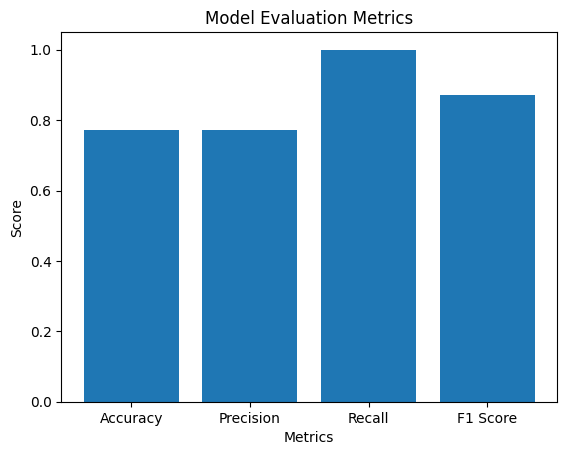

In [12]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)

plt.title("Model Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")

plt.show()